# Nama:
# NIM:
# Kelas:

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [5]:
df = pd.read_csv('berat_tinggi.csv')

## EDA

Text(0.5, 1.0, 'Sebaran Nilai berat vs tinggi')

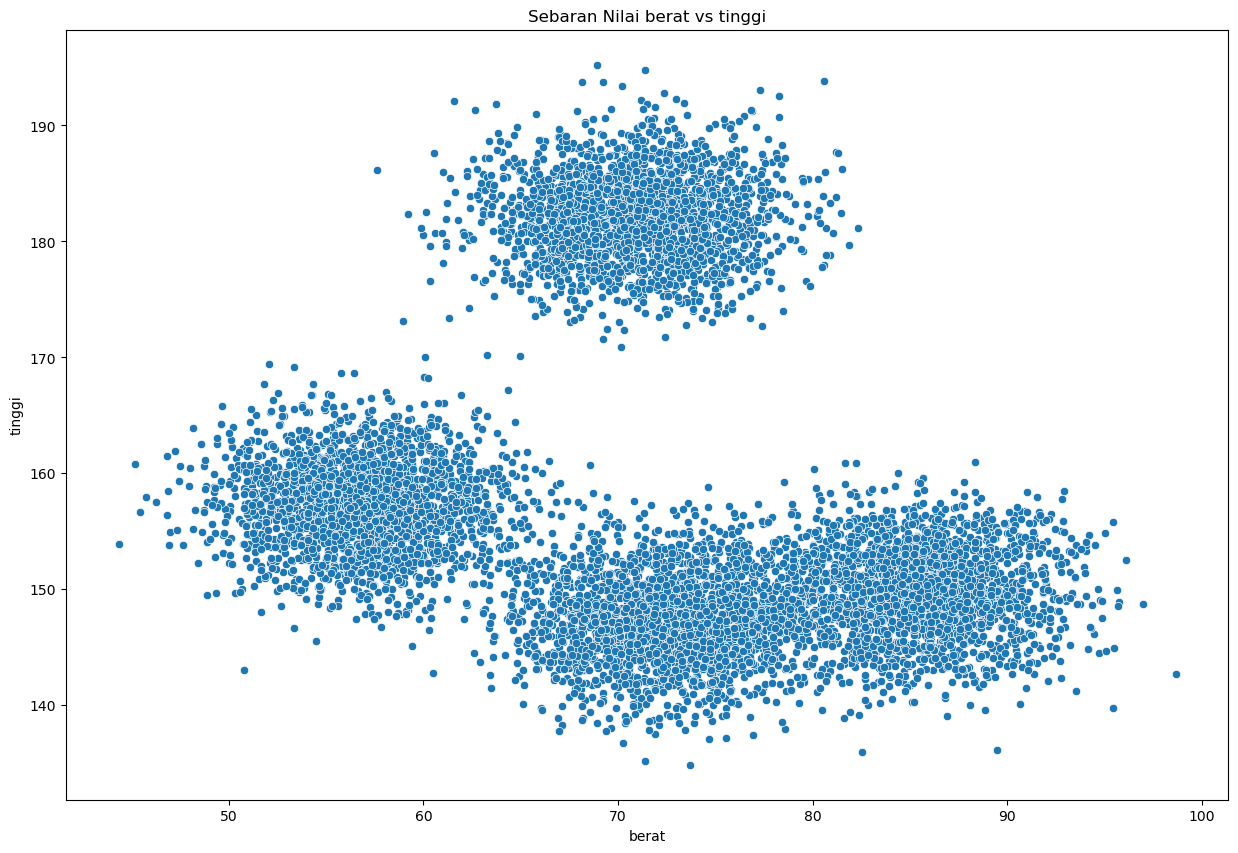

In [6]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi')
plt.title('Sebaran Nilai berat vs tinggi')

In [7]:
df.describe()

,tinggi,berat
count,8888.000000,8888.000000
mean,159.125498,71.365302
std,14.258305,10.729120
min,134.881305,44.344643
25%,148.522565,63.557079
50%,153.805704,71.748643
75%,170.365514,79.003827
max,195.232920,98.644868


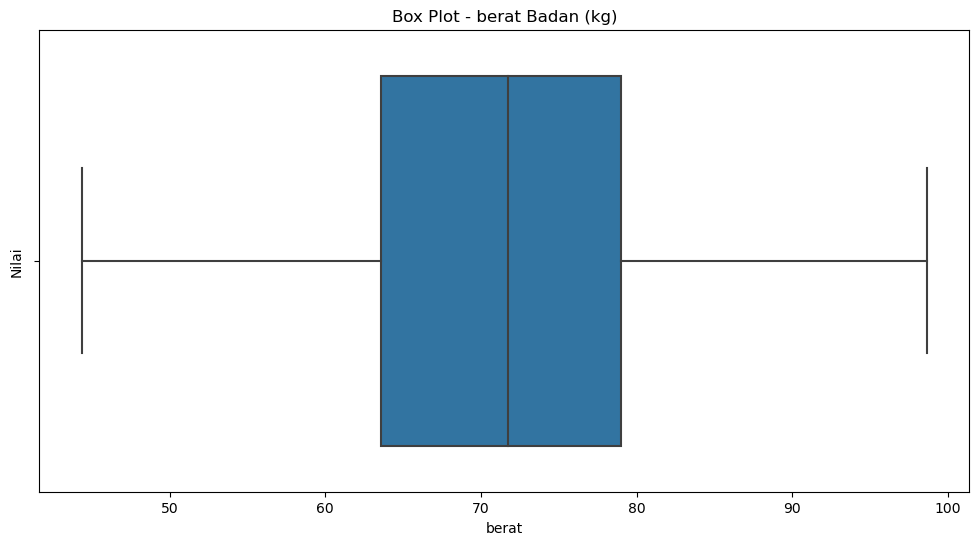

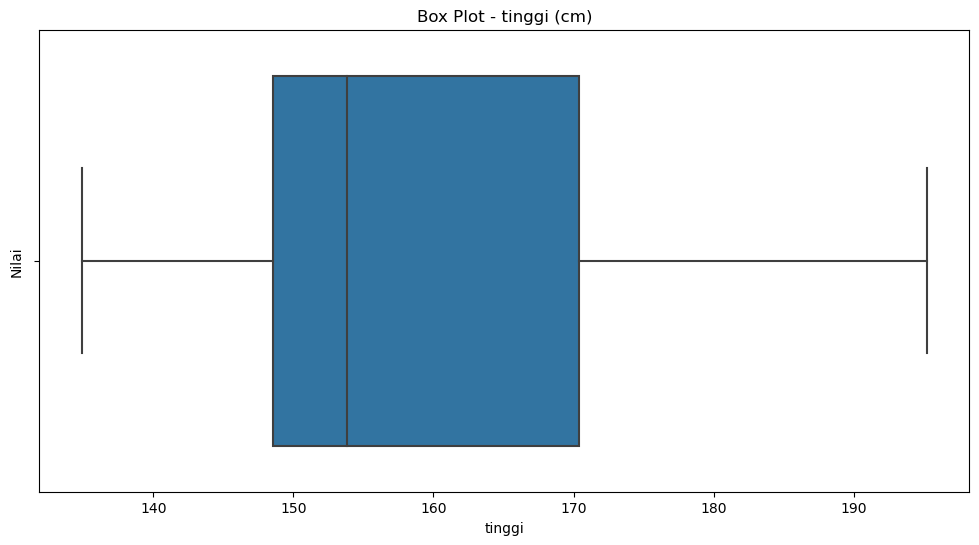

In [8]:
# Looping untuk kolom 'berat' dan 'tinggi'
columns = ['berat', 'tinggi']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

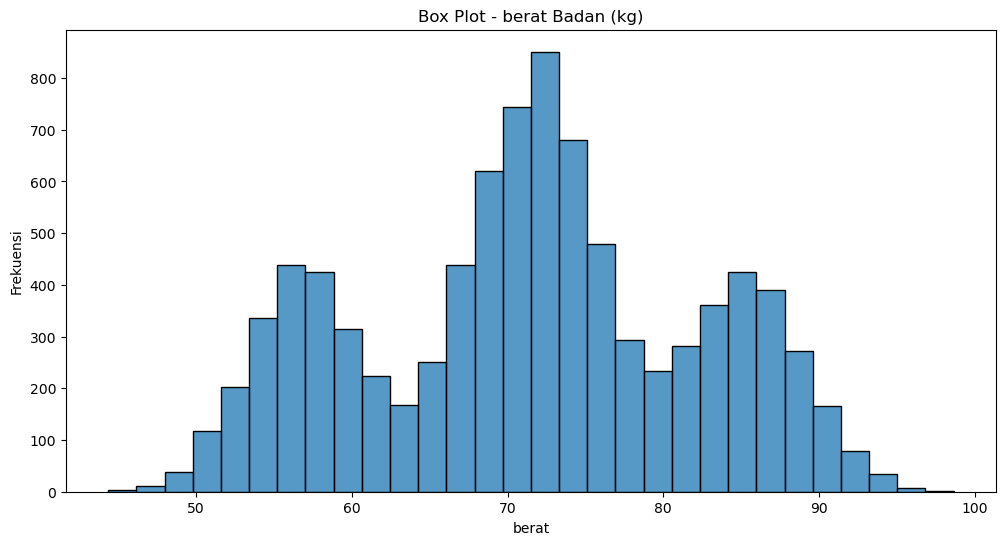

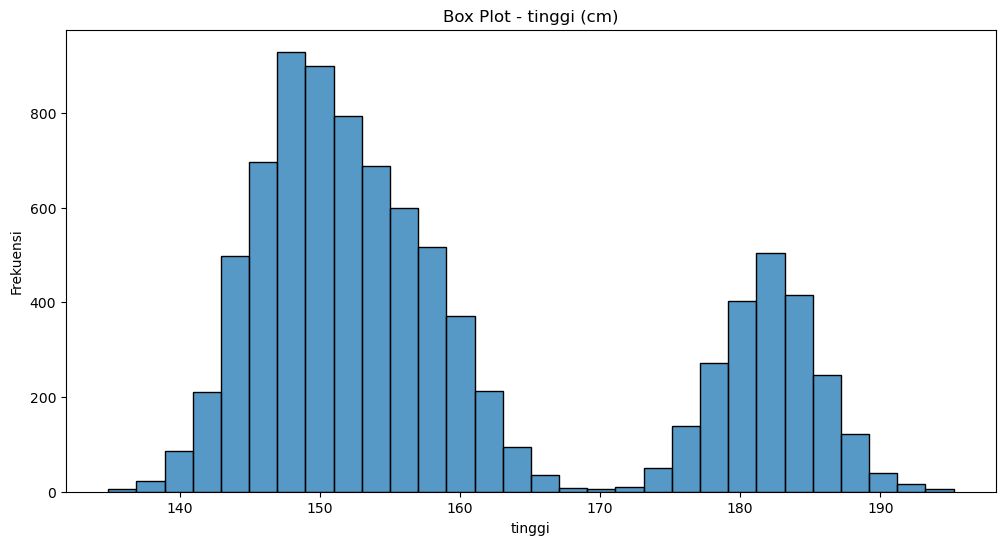

In [9]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [10]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 8888
Dataframe dimension after duplication drop 8888


dari hasil running program diatas, tidak ada data yg duplikat

In [11]:
fitur_columns = ['berat', 'tinggi']
X = df[fitur_columns].values
y = df['deskripsi'].values #anotator label

In [12]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,berat,tinggi
count,8.888000e+03,8.888000e+03
mean,3.785351e-16,-1.893375e-15
std,1.000056e+00,1.000056e+00
min,-2.518583e+00,-1.700451e+00
25%,-7.278008e-01,-7.436739e-01
50%,3.573103e-02,-3.731224e-01
75%,7.119833e-01,7.883579e-01
max,2.542716e+00,2.532521e+00


In [13]:
X_std

array([[-1.2118229 , -0.07092171],
       [-1.75281897,  0.08546572],
       [-0.87900786,  0.16556767],
       ...,
       [-0.89346332, -0.02015625],
       [-1.6141688 , -0.17762697],
       [ 1.40264032, -0.3111536 ]])

In [14]:
df_scalling

,berat,tinggi
0,-1.211823,-0.070922
1,-1.752819,0.085466
2,-0.879008,0.165568
3,-0.216544,1.636598
4,-0.002258,1.777105
...,...,...
8883,0.329937,1.274490
8884,0.905892,-0.527475
8885,-0.893463,-0.020156
8886,-1.614169,-0.177627


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

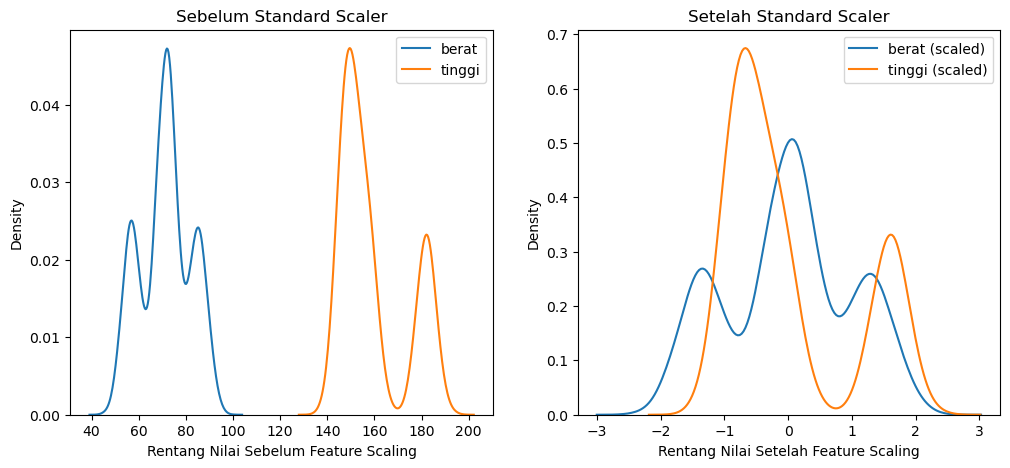

In [15]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = df[['berat', 'tinggi']]

scaler = StandardScaler()
scaled = scaler.fit_transform(data)

# ubah hasil scaling jadi dataframe
df_scaling = pd.DataFrame(scaled, columns=['berat', 'tinggi'])

# membuat subplot
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Sebelum Standard Scaler')

sns.kdeplot(df['berat'], ax=ax1, label='berat')
sns.kdeplot(df['tinggi'], ax=ax1, label='tinggi')

ax2.set_title('Setelah Standard Scaler')

sns.kdeplot(df_scaling['berat'], ax=ax2, label='berat (scaled)')
sns.kdeplot(df_scaling['tinggi'], ax=ax2, label='tinggi (scaled)')

ax1.set_xlabel('Rentang Nilai Sebelum Feature Scaling')
ax2.set_xlabel('Rentang Nilai Setelah Feature Scaling')

ax1.set_ylabel('Density')
ax2.set_ylabel('Density')

ax1.legend()
ax2.legend()

plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1.Berdasarkan visualisasi tersebut, sebelum dilakukan Standard Scaler terlihat bahwa fitur **berat** dan **tinggi** memiliki rentang nilai yang berbeda jauh sehingga distribusinya tidak seimbang dan berpotensi menyebabkan algoritma K-Means menjadi bias terhadap fitur dengan skala lebih besar, yaitu tinggi. Setelah dilakukan scaling, kedua fitur telah dinormalisasi ke rentang yang seragam dan terpusat di sekitar nol, sehingga distribusinya menjadi lebih sebanding. Hal ini menunjukkan bahwa proses Standard Scaler berhasil membuat setiap fitur memiliki kontribusi yang sama dalam perhitungan jarak, sehingga hasil clustering K-Means menjadi lebih akurat, stabil, dan representatif terhadap pola data yang sebenarnya.


## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

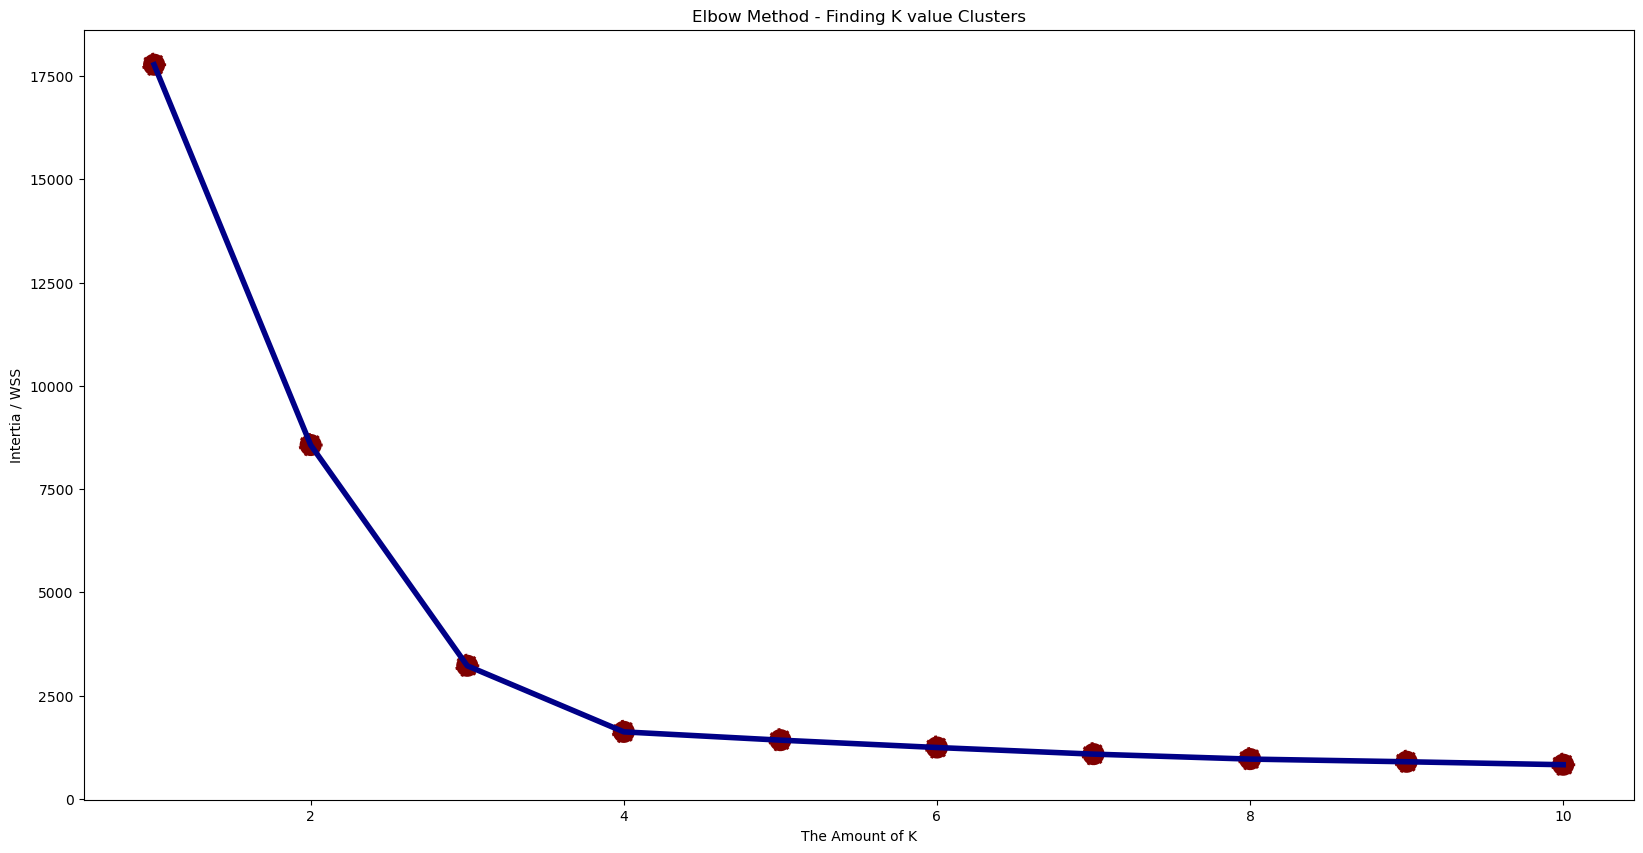

In [16]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [17]:
#Dari hasil diatas elbow nya dipilih pada angka 4,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=4, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=4, random_state=0)

In [18]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [19]:
df

,tinggi,berat,deskripsi,cluster_elbow
0,158.114332,58.364240,Normal,0
1,160.344026,52.560155,Normal,0
2,161.486080,61.934852,Normal,0
3,182.459297,69.042108,Slim,2
4,184.462584,71.341076,Slim,2
...,...,...,...,...
8883,177.296550,74.905033,Slim,2
8884,151.605026,81.084183,Obese,3
8885,158.838120,61.779766,Normal,0
8886,156.592981,54.047666,Normal,0


<Axes: xlabel='berat', ylabel='tinggi'>

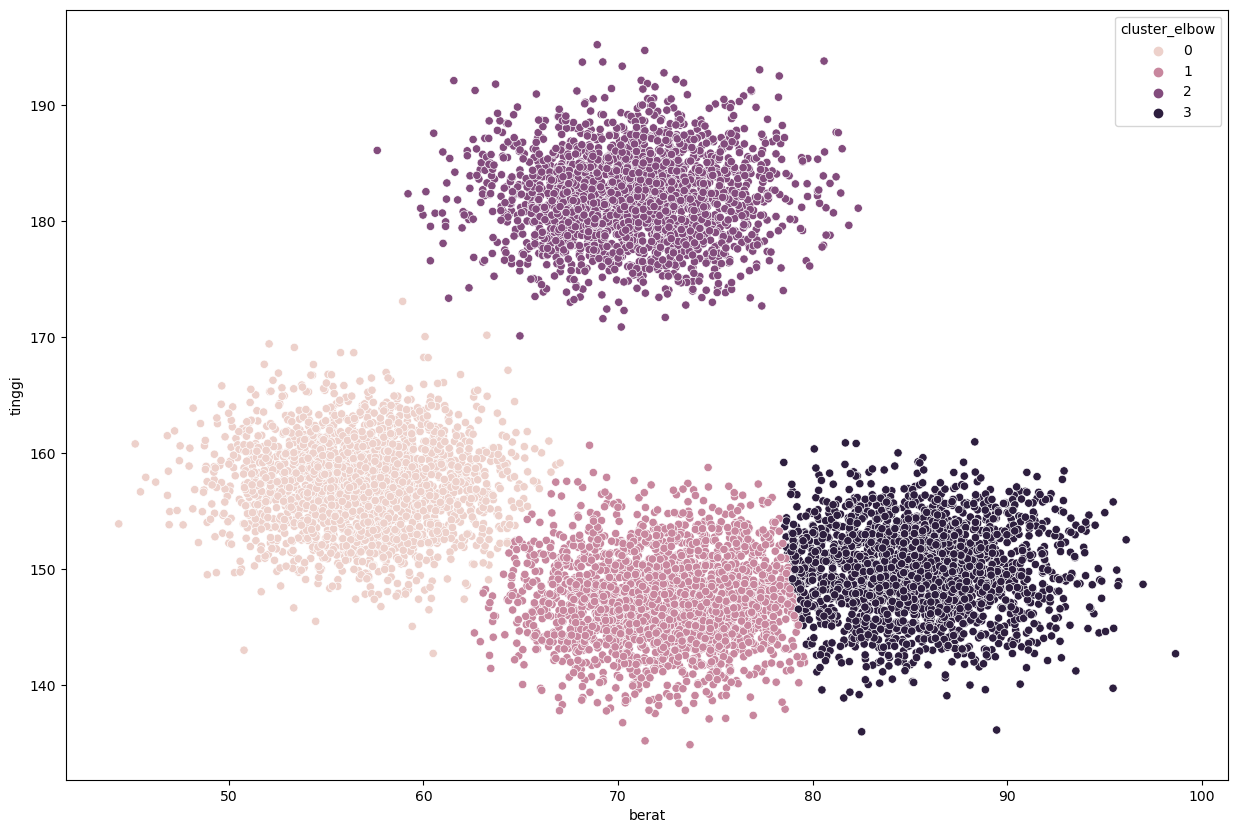

In [20]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi', hue='cluster_elbow')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='berat', ylabel='tinggi'>

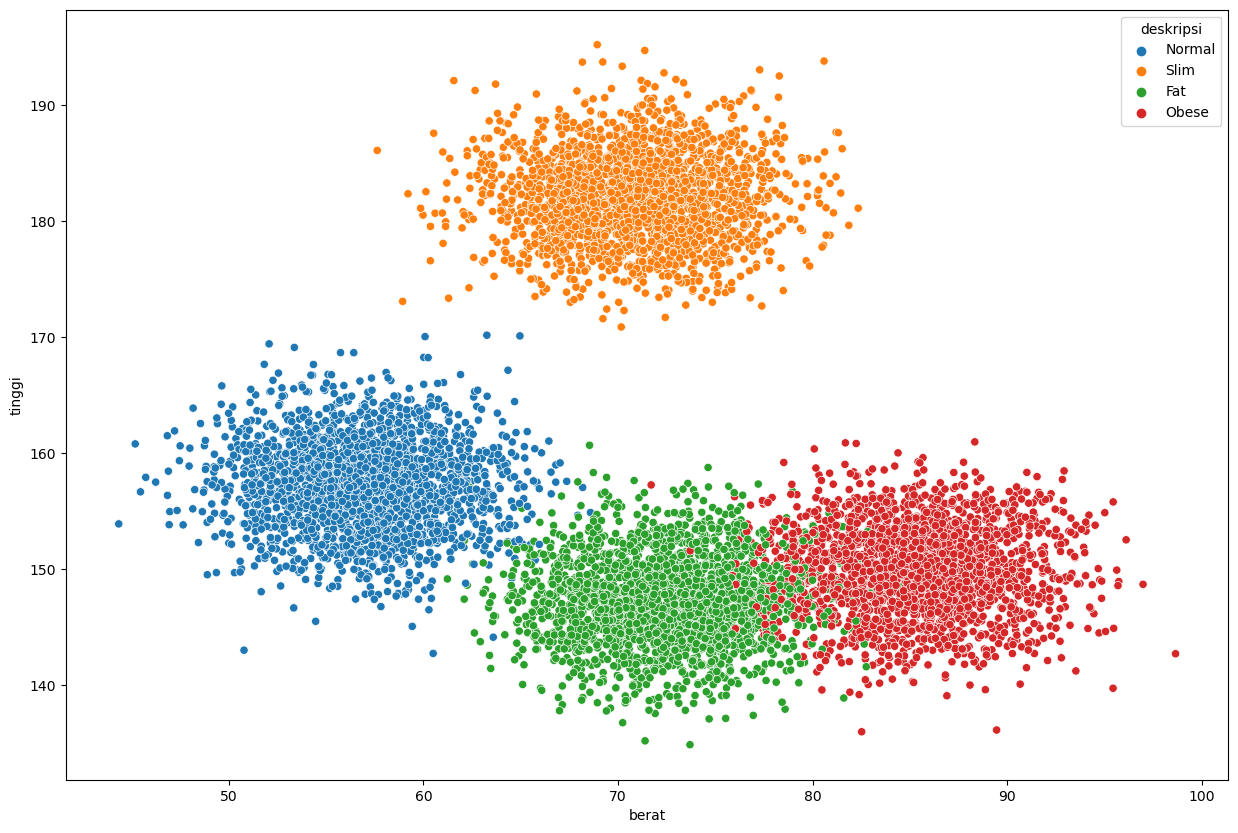

In [21]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi',hue='deskripsi')

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
1. Cluster 0 -> Normal
2. Cluster 1 -> Fat
3. Cluster 2 -> Slim
4. Cluster 3 -> Obese

### 2. Via Score Plot

In [22]:
!pip install yellowbrick

     -------------------------------------- 282.6/282.6 kB 3.5 MB/s eta 0:00:00


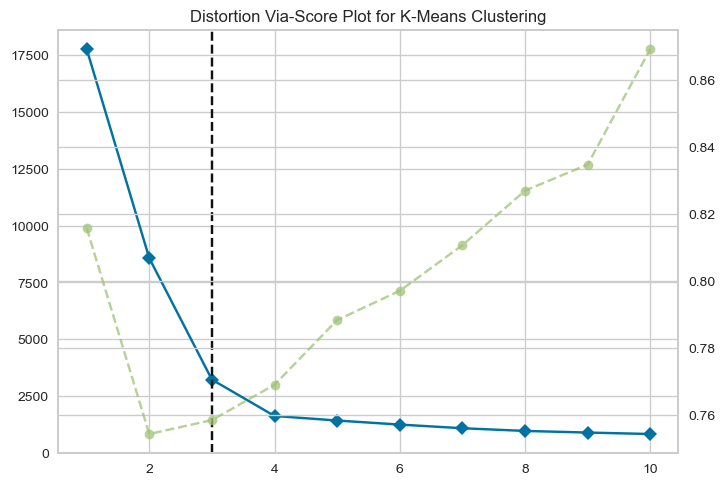

In [23]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [24]:
# Dari hasil diatas K-nya dipilih pada angka 3,
# karena titik distorsinya bertemu pada nilai 3 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [25]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [26]:
df

,tinggi,berat,deskripsi,cluster_elbow,cluster_via
0,158.114332,58.364240,Normal,0,2
1,160.344026,52.560155,Normal,0,2
2,161.486080,61.934852,Normal,0,2
3,182.459297,69.042108,Slim,2,1
4,184.462584,71.341076,Slim,2,1
...,...,...,...,...,...
8883,177.296550,74.905033,Slim,2,1
8884,151.605026,81.084183,Obese,3,0
8885,158.838120,61.779766,Normal,0,2
8886,156.592981,54.047666,Normal,0,2


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

<Axes: xlabel='berat', ylabel='tinggi'>

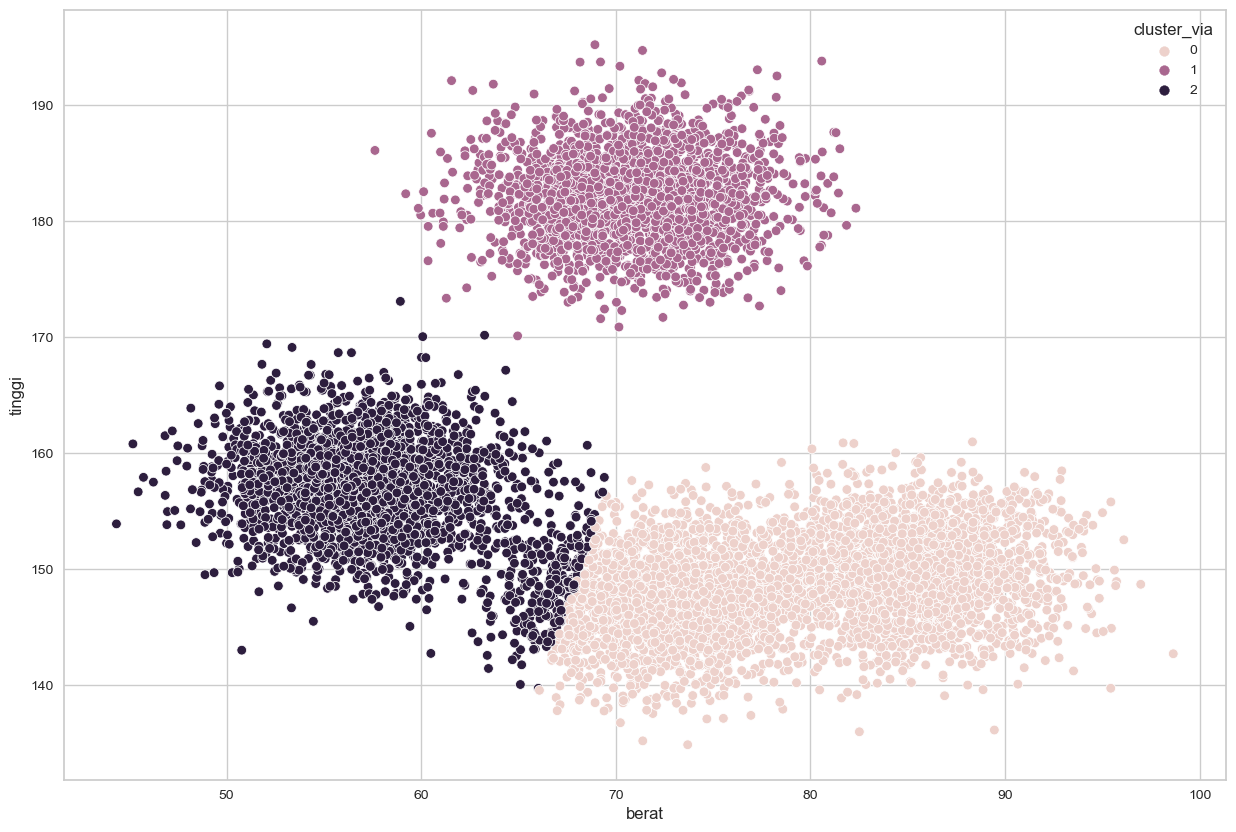

In [32]:
#Lakukan evaluasi setelah dilakukan K-Means
#Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi', hue='cluster_via')

### Bandingkan dengan label anotator

<Axes: xlabel='berat', ylabel='tinggi'>

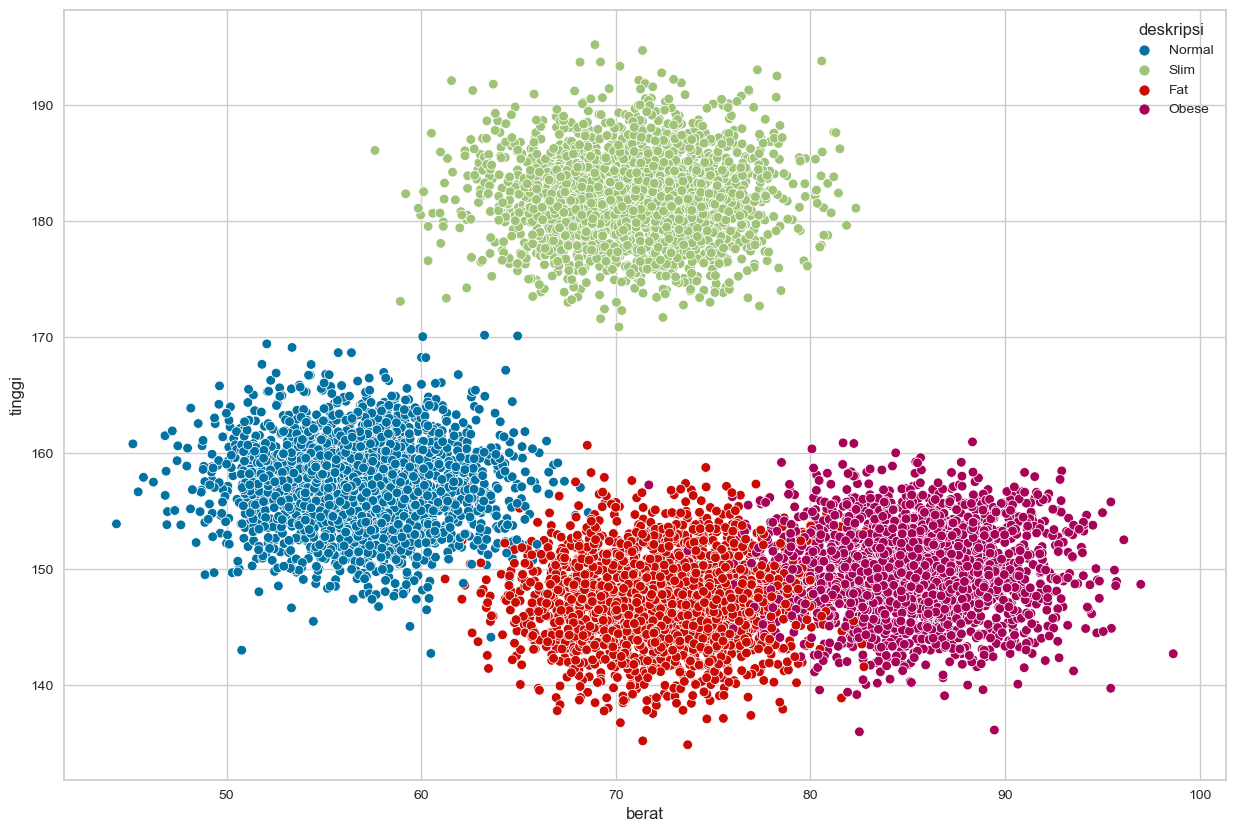

In [34]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi',hue='deskripsi')

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1.Berdasarkan visualisasi scatter plot tersebut, terlihat bahwa hasil clustering K-Means berhasil membagi data menjadi empat kelompok yang cukup jelas, yaitu **Normal (biru), Slim (hijau), Fat (merah), dan Obese (ungu)** berdasarkan kombinasi tinggi dan berat badan. Cluster **Slim** berada pada area tinggi badan lebih tinggi dengan berat relatif lebih ringan, sedangkan **Normal** berada di tengah dengan distribusi yang seimbang. Sementara itu, cluster **Fat** dan **Obese** cenderung berada pada tinggi yang lebih rendah dengan berat yang lebih besar, dengan **Obese** memiliki nilai berat paling tinggi dibanding cluster lainnya. Pemisahan antar cluster terlihat cukup tegas dengan sedikit overlap, yang menunjukkan bahwa K-Means mampu mengelompokkan data secara efektif dan pola distribusi data dapat ditangkap dengan baik. Namun, masih terdapat sedikit tumpang tindih di beberapa area batas cluster, yang menandakan bahwa karakteristik antar kategori tidak sepenuhnya terpisah secara sempurna. Secara keseluruhan, hasil ini menunjukkan bahwa jumlah cluster yang digunakan sudah cukup representatif dalam menggambarkan struktur data.



### Thank you :)